# Q4: Simple CNN for Classification + BBox Regression

This notebook is intentionally minimal and avoids SE blocks or heavy tricks. It loads Oxford Pets, applies a basic resize + normalize transform, trains a small CNN, and visualizes one prediction.

In [41]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from datasets import load_dataset
import pytorch_lightning as pl
import torchmetrics
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(67)
np.random.seed(67)
random.seed(67)

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")
torch.set_float32_matmul_precision('high')

Using cuda


In [43]:
# Dataset + simple transform (with light augmentation for train)
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

_color_jitter = transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)

def _scale_bbox(box, orig_w, orig_h, new_w, new_h):
    x1, y1, x2, y2 = box
    sx = new_w / orig_w
    sy = new_h / orig_h
    return [x1 * sx, y1 * sy, x2 * sx, y2 * sy]

def _transform_one(img, bbox, train=False):
    orig_w, orig_h = img.size
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    bbox = _scale_bbox(bbox, orig_w, orig_h, IMG_SIZE, IMG_SIZE)

    if train and random.random() < 0.5:
        img = TF.hflip(img)
        x1, y1, x2, y2 = bbox
        bbox = [IMG_SIZE - x2, y1, IMG_SIZE - x1, y2]

    if train and random.random() < 0.3:
        img = _color_jitter(img)

    img = TF.to_tensor(img)
    img = TF.normalize(img, mean=MEAN, std=STD)
    bbox = torch.tensor([b / IMG_SIZE for b in bbox], dtype=torch.float32)
    return img, bbox

def transform_example(example, train=False):
    imgs = example["img"]
    bboxes = example["bbox"]
    if isinstance(imgs, list):
        new_imgs = []
        new_boxes = []
        for i, img in enumerate(imgs):
            img_t, box_t = _transform_one(img, bboxes[i], train=train)
            new_imgs.append(img_t)
            new_boxes.append(box_t)
        example["img"] = new_imgs
        example["bbox"] = new_boxes
    else:
        img_t, box_t = _transform_one(imgs, bboxes, train=train)
        example["img"] = img_t
        example["bbox"] = box_t
    return example

def transform_train(example):
    return transform_example(example, train=True)

def transform_eval(example):
    return transform_example(example, train=False)

_ds = load_dataset("cvdl/oxford-pets")

# Keep only needed columns to avoid collate issues
keep_cols = {"img", "bbox", "category"}
for split_name in ["train", "valid", "test"]:
    cols = list(_ds[split_name].column_names)
    drop_cols = [c for c in cols if c not in keep_cols]
    if drop_cols:
        _ds[split_name] = _ds[split_name].remove_columns(drop_cols)

train_ds = _ds["train"].with_transform(transform_train)
valid_ds = _ds["valid"].with_transform(transform_eval)
test_ds = _ds["test"].with_transform(transform_eval)

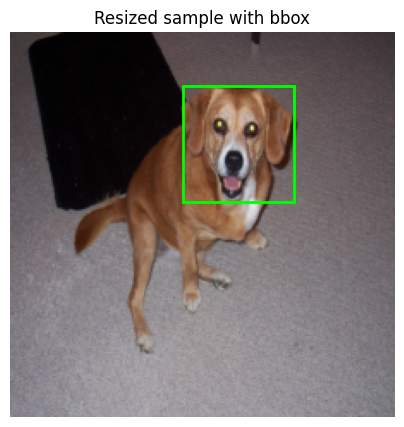

In [44]:
# Quick check: visualize a random resized sample with bbox
def _denorm(img):
    img = img.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

idx = random.randrange(len(train_ds))
sample = train_ds[idx]
img = sample["img"]
bbox = (sample["bbox"] * IMG_SIZE).tolist()

def _to_xyxy(b):
    return [min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3])]

x1, y1, x2, y2 = _to_xyxy(bbox)
img_vis = _denorm(img).permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_vis)
ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2, edgecolor="lime", facecolor="none"))
ax.set_title("Resized sample with bbox")
ax.axis("off")
plt.show()

In [45]:
# DataLoaders
BATCH_SIZE = 64
NUM_WORKERS = 0

def make_loaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, valid_loader, test_loader

train_loader, valid_loader, test_loader = make_loaders()
print("Data loaders ready")

Data loaders ready


In [46]:
# IoU and mAP metric functions
def compute_iou(pred_bbox, gt_bbox):
    """
    Compute Intersection over Union between predicted and ground truth bounding boxes.
    Boxes are in format [x1, y1, x2, y2] and normalized to [0, 1].
    """
    # Convert to xyxy format if needed
    pred_x1, pred_y1, pred_x2, pred_y2 = pred_bbox
    gt_x1, gt_y1, gt_x2, gt_y2 = gt_bbox
    
    # Ensure correct ordering (x1 < x2, y1 < y2)
    pred_x1, pred_x2 = min(pred_x1, pred_x2), max(pred_x1, pred_x2)
    pred_y1, pred_y2 = min(pred_y1, pred_y2), max(pred_y1, pred_y2)
    gt_x1, gt_x2 = min(gt_x1, gt_x2), max(gt_x1, gt_x2)
    gt_y1, gt_y2 = min(gt_y1, gt_y2), max(gt_y1, gt_y2)
    
    # Compute intersection
    inter_x1 = max(pred_x1, gt_x1)
    inter_y1 = max(pred_y1, gt_y1)
    inter_x2 = min(pred_x2, gt_x2)
    inter_y2 = min(pred_y2, gt_y2)
    
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    
    # Compute union
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)
    union_area = pred_area + gt_area - inter_area
    
    # Compute IoU
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

def compute_batch_iou(pred_bboxes, gt_bboxes):
    """
    Compute IoU for a batch of bounding boxes.
    Args:
        pred_bboxes: torch.Tensor of shape (batch_size, 4)
        gt_bboxes: torch.Tensor of shape (batch_size, 4)
    Returns:
        torch.Tensor of shape (batch_size,) with IoU values
    """
    ious = []
    for i in range(pred_bboxes.shape[0]):
        pred = pred_bboxes[i].cpu().numpy() if torch.is_tensor(pred_bboxes[i]) else pred_bboxes[i]
        gt = gt_bboxes[i].cpu().numpy() if torch.is_tensor(gt_bboxes[i]) else gt_bboxes[i]
        iou = compute_iou(pred, gt)
        ious.append(iou)
    return torch.tensor(ious)

def compute_ap(precisions, recalls):
    """
    Compute Average Precision using 11-point interpolation.
    """
    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11.0
    return ap

def compute_map(pred_labels, pred_bboxes, gt_labels, gt_bboxes, num_classes, iou_threshold=0.5):
    """
    Compute mean Average Precision for object detection.
    
    Args:
        pred_labels: predicted class labels (batch_size,)
        pred_bboxes: predicted bounding boxes (batch_size, 4)
        gt_labels: ground truth class labels (batch_size,)
        gt_bboxes: ground truth bounding boxes (batch_size, 4)
        num_classes: total number of classes
        iou_threshold: IoU threshold for considering a detection as correct
    
    Returns:
        mAP score
    """
    # Compute IoUs for all predictions
    ious = compute_batch_iou(pred_bboxes, gt_bboxes)
    
    aps = []
    for cls in range(num_classes):
        # Get predictions and ground truths for this class
        gt_mask = gt_labels == cls
        pred_mask = pred_labels == cls
        
        if not gt_mask.any():
            continue
        
        # True positives: correct class and IoU > threshold
        tp = (pred_mask & gt_mask & (ious > iou_threshold)).float()
        fp = (pred_mask & (~gt_mask | (ious <= iou_threshold))).float()
        
        # Compute precision and recall
        tp_cumsum = torch.cumsum(tp, dim=0)
        fp_cumsum = torch.cumsum(fp, dim=0)
        
        recalls = tp_cumsum / gt_mask.sum().float()
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-10)
        
        # Compute AP for this class
        ap = compute_ap(precisions.cpu().numpy(), recalls.cpu().numpy())
        aps.append(ap)
    
    # Return mean AP across all classes
    return np.mean(aps) if aps else 0.0

print("Metrics functions ready")

Metrics functions ready


In [47]:
class SimpleCNN(pl.LightningModule):
    def __init__(self, num_classes=37, lr=1e-3, bbox_loss_weight=3.0, bbox_lr_mult=2.0):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.bbox_loss_weight = bbox_loss_weight
        self.bbox_lr_mult = bbox_lr_mult
        self.num_classes = num_classes

        # Simple but stronger: more channels + extra block
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        
        # Unified pooling for better feature sharing
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.dropout = nn.Dropout(0.4)
        self.class_head = nn.Sequential(
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        # Improved bbox head with less aggressive compression
        self.bbox_head = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        
        # Add lists to track IoU and mAP during validation and testing
        self.val_ious = []
        self.val_pred_labels = []
        self.val_pred_bboxes = []
        self.val_gt_labels = []
        self.val_gt_bboxes = []
        
        self.test_ious = []
        self.test_pred_labels = []
        self.test_pred_bboxes = []
        self.test_gt_labels = []
        self.test_gt_bboxes = []

    def forward(self, x):
        feats = self.features(x)
        
        # Shared pooling
        pooled = self.pool(feats).view(x.size(0), -1)
        
        class_feats = self.dropout(pooled)
        class_logits = self.class_head(class_feats)
        
        # Return raw bbox logits (no sigmoid here)
        bbox = self.bbox_head(pooled)
        return class_logits, bbox
    
    def _unpack(self, batch):
        if isinstance(batch, dict):
            images = batch["img"]
            labels = batch["category"]
            bboxes = batch["bbox"]
        else:
            images, labels, bboxes = batch
        if not torch.is_tensor(bboxes):
            bboxes = torch.tensor(bboxes, device=images.device, dtype=torch.float32)
        bboxes = bboxes.float()
        labels = labels.long()
        return images, labels, bboxes

    def _shared_step(self, batch):
        images, labels, bboxes = self._unpack(batch)
        logits, pred_bboxes = self(images)
        loss_cls = F.cross_entropy(logits, labels)
        # Apply sigmoid here for loss computation
        pred_bboxes_norm = torch.sigmoid(pred_bboxes)
        loss_bbox = F.smooth_l1_loss(pred_bboxes_norm, bboxes)
        loss = loss_cls + self.bbox_loss_weight * loss_bbox
        preds = torch.argmax(logits, dim=1)
        return loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes

    def training_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        self.log("train_cls_loss", loss_cls)
        self.log("train_bbox_loss", loss_bbox)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.val_acc(preds, labels)
        
        # Compute IoU for this batch
        ious = compute_batch_iou(pred_bboxes_norm, bboxes)
        mean_iou = ious.mean()
        
        # Store for mAP computation
        self.val_ious.extend(ious.tolist())
        self.val_pred_labels.append(preds.cpu())
        self.val_pred_bboxes.append(pred_bboxes_norm.cpu())
        self.val_gt_labels.append(labels.cpu())
        self.val_gt_bboxes.append(bboxes.cpu())
        
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)
        self.log("val_cls_loss", loss_cls)
        self.log("val_bbox_loss", loss_bbox)
        self.log("val_iou", mean_iou, prog_bar=True)

    def on_validation_epoch_end(self):
        if len(self.val_pred_labels) > 0:
            # Concatenate all batches
            pred_labels = torch.cat(self.val_pred_labels)
            pred_bboxes = torch.cat(self.val_pred_bboxes)
            gt_labels = torch.cat(self.val_gt_labels)
            gt_bboxes = torch.cat(self.val_gt_bboxes)
            
            # Compute mAP
            map_score = compute_map(pred_labels, pred_bboxes, gt_labels, gt_bboxes, 
                                   self.num_classes, iou_threshold=0.5)
            
            # Compute mean IoU
            mean_iou = np.mean(self.val_ious)
            
            self.log("val_map", map_score, prog_bar=True)
            self.log("val_mean_iou", mean_iou)
            
            # Clear the lists for next epoch
            self.val_ious = []
            self.val_pred_labels = []
            self.val_pred_bboxes = []
            self.val_gt_labels = []
            self.val_gt_bboxes = []

    def test_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.test_acc(preds, labels)
        
        # Compute IoU for this batch
        ious = compute_batch_iou(pred_bboxes_norm, bboxes)
        mean_iou = ious.mean()
        
        # Store for mAP computation
        self.test_ious.extend(ious.tolist())
        self.test_pred_labels.append(preds.cpu())
        self.test_pred_bboxes.append(pred_bboxes_norm.cpu())
        self.test_gt_labels.append(labels.cpu())
        self.test_gt_bboxes.append(bboxes.cpu())
        
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc, prog_bar=True)
        self.log("test_cls_loss", loss_cls)
        self.log("test_bbox_loss", loss_bbox)
        self.log("test_iou", mean_iou, prog_bar=True)

    def on_test_epoch_end(self):
        if len(self.test_pred_labels) > 0:
            # Concatenate all batches
            pred_labels = torch.cat(self.test_pred_labels)
            pred_bboxes = torch.cat(self.test_pred_bboxes)
            gt_labels = torch.cat(self.test_gt_labels)
            gt_bboxes = torch.cat(self.test_gt_bboxes)
            
            # Compute mAP
            map_score = compute_map(pred_labels, pred_bboxes, gt_labels, gt_bboxes, 
                                   self.num_classes, iou_threshold=0.5)
            
            # Compute mean IoU
            mean_iou = np.mean(self.test_ious)
            
            self.log("test_map", map_score, prog_bar=True)
            self.log("test_mean_iou", mean_iou)
            
            # Clear the lists
            self.test_ious = []
            self.test_pred_labels = []
            self.test_pred_bboxes = []
            self.test_gt_labels = []
            self.test_gt_bboxes = []

    def configure_optimizers(self):
        return torch.optim.Adam(
            [
                {"params": self.features.parameters(), "lr": self.lr},
                {"params": self.class_head.parameters(), "lr": self.lr},
                {"params": self.bbox_head.parameters(), "lr": self.lr * self.bbox_lr_mult},
            ]
        )

print("SimpleCNN ready with IoU and mAP metrics")

SimpleCNN ready with IoU and mAP metrics


In [48]:
# Train (keep epochs small for a quick run)
model = SimpleCNN(num_classes=37, lr=1e-3, bbox_loss_weight=5.0, bbox_lr_mult=2)
trainer = pl.Trainer(max_epochs=10, accelerator=device, log_every_n_steps=10)
trainer.fit(model, train_loader, valid_loader)
trainer.test(model, test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | features   | Sequential         | 1.2 M  | train | 0    
1 | pool       | AdaptiveAvgPool2d  | 0      | train | 0    
2 | dropout    | Dropout            | 0      | train | 0    
3 | class_head | Sequential         | 1.1 M  | train | 0    
4 | bbox_head  | Sequential         | 2.2 M  | train | 0    
5 | train_acc  | MulticlassAccuracy | 0      | train | 0    
6 | val_acc    | MulticlassAccuracy | 0      | train | 0    
7 | test_acc   | MulticlassAccuracy | 0      | train | 0    
--------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\danib\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


c:\Users\danib\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 41/41 [00:20<00:00,  1.99it/s, v_num=76, train_loss=2.930, train_acc=0.143, val_loss=3.170, val_acc=0.131, val_iou=0.369, val_map=0.0124]   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 41/41 [00:20<00:00,  1.97it/s, v_num=76, train_loss=2.930, train_acc=0.143, val_loss=3.170, val_acc=0.131, val_iou=0.369, val_map=0.0124]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\danib\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.1215880885720253
     test_bbox_loss         0.0106461551040411
      test_cls_loss          3.211029291152954
        test_iou            0.34481197595596313
        test_loss           3.2642600536346436
        test_map           0.005561760161072016
      test_mean_iou         0.3448120057582855
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 3.2642600536346436,
  'test_acc': 0.1215880885720253,
  'test_cls_loss': 3.211029291152954,
  'test_bbox_loss': 0.0106461551040411,
  'test_iou': 0.34481197595596313,
  'test_map': 0.005561760161072016,
  'test_mean_iou': 0.3448120057582855}]

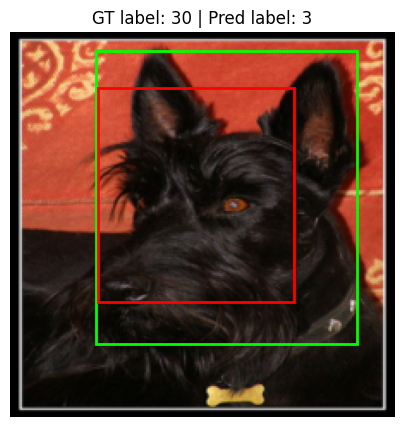

[50.759681701660156, 31.822086334228516, 164.61378479003906, 156.83876037597656]


In [49]:
# Visualize one prediction
def denormalize(img):
    img = img.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

model = model.to(device)
model.eval()
idx = random.randrange(len(test_ds))
sample = test_ds[idx]
img = sample["img"]
gt_bbox = (sample["bbox"] * IMG_SIZE).tolist()
gt_label = int(sample["category"])

with torch.no_grad():
    logits, pred_bbox = model(img.unsqueeze(0).to(device))
    pred_label = int(torch.argmax(logits, dim=1).item())
    # Apply sigmoid for visualization since forward returns raw logits now
    pred_bbox = (torch.sigmoid(pred_bbox).squeeze(0).cpu() * IMG_SIZE).tolist()

def _to_xyxy(b):
    return [min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3])]

gt = _to_xyxy(gt_bbox)
pr = _to_xyxy(pred_bbox)

img_vis = denormalize(img).permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_vis)
ax.add_patch(patches.Rectangle((gt[0], gt[1]), gt[2] - gt[0], gt[3] - gt[1],
                               linewidth=2, edgecolor="lime", facecolor="none"))
ax.add_patch(patches.Rectangle((pr[0], pr[1]), pr[2] - pr[0], pr[3] - pr[1],
                               linewidth=2, edgecolor="red", facecolor="none"))
ax.set_title(f"GT label: {gt_label} | Pred label: {pred_label}")
ax.axis("off")
plt.show()
print(pr)

In [50]:
# Display metrics summary
print("\n" + "="*50)
print("METRICS SUMMARY")
print("="*50)

# Get logged metrics from trainer
if hasattr(trainer, 'callback_metrics'):
    metrics = trainer.callback_metrics
    print("\nTest Metrics:")
    print(f"  Accuracy: {metrics.get('test_acc', 0):.4f}")
    print(f"  Mean IoU: {metrics.get('test_mean_iou', 0):.4f}")
    print(f"  mAP@0.5: {metrics.get('test_map', 0):.4f}")
    print(f"  Classification Loss: {metrics.get('test_cls_loss', 0):.4f}")
    print(f"  BBox Loss: {metrics.get('test_bbox_loss', 0):.4f}")
    print(f"  Total Loss: {metrics.get('test_loss', 0):.4f}")
    
print("\n" + "="*50)


METRICS SUMMARY

Test Metrics:
  Accuracy: 0.1216
  Mean IoU: 0.3448
  mAP@0.5: 0.0056
  Classification Loss: 3.2110
  BBox Loss: 0.0106
  Total Loss: 3.2643



# Hyperparameter Analysis

In this section, we analyze the impact of different hyperparameters on model performance:
1. **Learning Rate**: How different learning rates affect convergence and final performance
2. **Number of Convolution Layers**: Impact of model depth on accuracy and IoU
3. **Filter Size**: Effect of different kernel sizes on feature extraction
4. **Batch Size**: How batch size influences training stability and performance

In [51]:
# Flexible CNN model for hyperparameter experiments
class FlexibleCNN(pl.LightningModule):
    def __init__(self, num_classes=37, lr=1e-3, bbox_loss_weight=3.0, bbox_lr_mult=2.0, 
                 num_conv_blocks=4, filter_size=3, base_channels=32):
        """
        Args:
            num_classes: Number of output classes
            lr: Learning rate
            bbox_loss_weight: Weight for bounding box loss
            bbox_lr_mult: Learning rate multiplier for bbox head
            num_conv_blocks: Number of convolutional blocks (2-5)
            filter_size: Kernel size for convolutions (3, 5, or 7)
            base_channels: Starting number of channels (doubled each block)
        """
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.bbox_loss_weight = bbox_loss_weight
        self.bbox_lr_mult = bbox_lr_mult
        self.num_classes = num_classes
        
        # Build flexible feature extractor
        layers = []
        in_channels = 3
        out_channels = base_channels
        padding = filter_size // 2
        
        for i in range(num_conv_blocks):
            # Two conv layers per block
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=filter_size, padding=padding),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=filter_size, padding=padding),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2),
            ])
            in_channels = out_channels
            out_channels = min(out_channels * 2, 512)  # Cap at 512 channels
        
        self.features = nn.Sequential(*layers)
        
        # Compute feature map size after pooling
        final_channels = in_channels
        feature_size = IMG_SIZE // (2 ** num_conv_blocks)
        flat_size = final_channels * feature_size * feature_size
        
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        flat_size = final_channels * 4 * 4
        
        self.dropout = nn.Dropout(0.4)
        self.class_head = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.bbox_head = nn.Sequential(
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        
        self.val_ious = []
        self.val_pred_labels = []
        self.val_pred_bboxes = []
        self.val_gt_labels = []
        self.val_gt_bboxes = []
        
        self.test_ious = []
        self.test_pred_labels = []
        self.test_pred_bboxes = []
        self.test_gt_labels = []
        self.test_gt_bboxes = []

    def forward(self, x):
        feats = self.features(x)
        pooled = self.pool(feats).view(x.size(0), -1)
        
        class_feats = self.dropout(pooled)
        class_logits = self.class_head(class_feats)
        bbox = self.bbox_head(pooled)
        return class_logits, bbox
    
    def _unpack(self, batch):
        if isinstance(batch, dict):
            images = batch["img"]
            labels = batch["category"]
            bboxes = batch["bbox"]
        else:
            images, labels, bboxes = batch
        if not torch.is_tensor(bboxes):
            bboxes = torch.tensor(bboxes, device=images.device, dtype=torch.float32)
        bboxes = bboxes.float()
        labels = labels.long()
        return images, labels, bboxes

    def _shared_step(self, batch):
        images, labels, bboxes = self._unpack(batch)
        logits, pred_bboxes = self(images)
        loss_cls = F.cross_entropy(logits, labels)
        pred_bboxes_norm = torch.sigmoid(pred_bboxes)
        loss_bbox = F.smooth_l1_loss(pred_bboxes_norm, bboxes)
        loss = loss_cls + self.bbox_loss_weight * loss_bbox
        preds = torch.argmax(logits, dim=1)
        return loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes

    def training_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        self.log("train_cls_loss", loss_cls)
        self.log("train_bbox_loss", loss_bbox)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.val_acc(preds, labels)
        
        ious = compute_batch_iou(pred_bboxes_norm, bboxes)
        mean_iou = ious.mean()
        
        self.val_ious.extend(ious.tolist())
        self.val_pred_labels.append(preds.cpu())
        self.val_pred_bboxes.append(pred_bboxes_norm.cpu())
        self.val_gt_labels.append(labels.cpu())
        self.val_gt_bboxes.append(bboxes.cpu())
        
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)
        self.log("val_cls_loss", loss_cls)
        self.log("val_bbox_loss", loss_bbox)
        self.log("val_iou", mean_iou, prog_bar=True)

    def on_validation_epoch_end(self):
        if len(self.val_pred_labels) > 0:
            pred_labels = torch.cat(self.val_pred_labels)
            pred_bboxes = torch.cat(self.val_pred_bboxes)
            gt_labels = torch.cat(self.val_gt_labels)
            gt_bboxes = torch.cat(self.val_gt_bboxes)
            
            map_score = compute_map(pred_labels, pred_bboxes, gt_labels, gt_bboxes, 
                                   self.num_classes, iou_threshold=0.5)
            mean_iou = np.mean(self.val_ious)
            
            self.log("val_map", map_score, prog_bar=True)
            self.log("val_mean_iou", mean_iou)
            
            self.val_ious = []
            self.val_pred_labels = []
            self.val_pred_bboxes = []
            self.val_gt_labels = []
            self.val_gt_bboxes = []

    def test_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels, pred_bboxes_norm, bboxes = self._shared_step(batch)
        self.test_acc(preds, labels)
        
        ious = compute_batch_iou(pred_bboxes_norm, bboxes)
        mean_iou = ious.mean()
        
        self.test_ious.extend(ious.tolist())
        self.test_pred_labels.append(preds.cpu())
        self.test_pred_bboxes.append(pred_bboxes_norm.cpu())
        self.test_gt_labels.append(labels.cpu())
        self.test_gt_bboxes.append(bboxes.cpu())
        
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc, prog_bar=True)
        self.log("test_cls_loss", loss_cls)
        self.log("test_bbox_loss", loss_bbox)
        self.log("test_iou", mean_iou, prog_bar=True)

    def on_test_epoch_end(self):
        if len(self.test_pred_labels) > 0:
            pred_labels = torch.cat(self.test_pred_labels)
            pred_bboxes = torch.cat(self.test_pred_bboxes)
            gt_labels = torch.cat(self.test_gt_labels)
            gt_bboxes = torch.cat(self.test_gt_bboxes)
            
            map_score = compute_map(pred_labels, pred_bboxes, gt_labels, gt_bboxes, 
                                   self.num_classes, iou_threshold=0.5)
            mean_iou = np.mean(self.test_ious)
            
            self.log("test_map", map_score, prog_bar=True)
            self.log("test_mean_iou", mean_iou)
            
            self.test_ious = []
            self.test_pred_labels = []
            self.test_pred_bboxes = []
            self.test_gt_labels = []
            self.test_gt_bboxes = []

    def configure_optimizers(self):
        return torch.optim.Adam(
            [
                {"params": self.features.parameters(), "lr": self.lr},
                {"params": self.class_head.parameters(), "lr": self.lr},
                {"params": self.bbox_head.parameters(), "lr": self.lr * self.bbox_lr_mult},
            ]
        )

print("FlexibleCNN ready for hyperparameter experiments")

FlexibleCNN ready for hyperparameter experiments


## 1. Learning Rate Analysis

In [ ]:
# Experiment 1: Learning Rate Influence
learning_rates = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3]
lr_results = []

print("Testing different learning rates...")
for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Training with learning rate: {lr}")
    print('='*50)
    
    model = FlexibleCNN(num_classes=37, lr=lr, bbox_loss_weight=5.0, bbox_lr_mult=2)
    trainer = pl.Trainer(
        max_epochs=50,  # Fewer epochs for faster experimentation
        accelerator=device,
        log_every_n_steps=10,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    
    trainer.fit(model, train_loader, valid_loader)
    test_results = trainer.test(model, test_loader, verbose=False)
    
    result = {
        'lr': lr,
        'test_acc': test_results[0]['test_acc'],
        'test_iou': test_results[0].get('test_mean_iou', 0),
        'test_map': test_results[0].get('test_map', 0),
        'test_loss': test_results[0]['test_loss']
    }
    lr_results.append(result)
    print(f"Results: Acc={result['test_acc']:.4f}, IoU={result['test_iou']:.4f}, mAP={result['test_map']:.4f}")

print("\n" + "="*50)
print("Learning Rate Experiment Complete!")
print("="*50)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Testing different learning rates...

Training with learning rate: 1e-05


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 35:  15%|█▍        | 6/41 [00:02<00:14,  2.37it/s, v_num=77, train_loss=3.080, train_acc=0.266, val_loss=3.070, val_acc=0.190, val_iou=0.449, val_map=0.0296]    

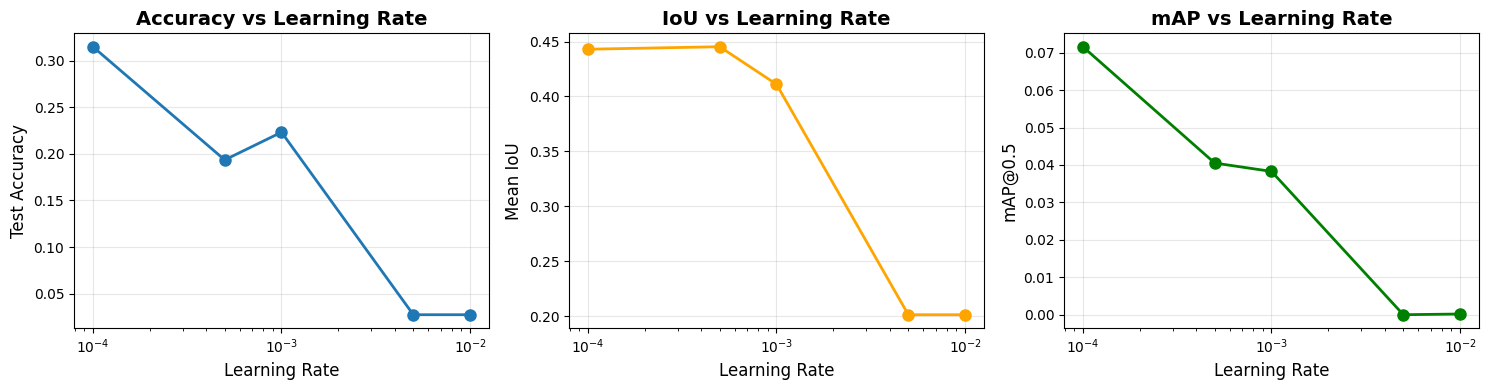


Learning Rate Analysis Summary:
------------------------------------------------------------
Best Accuracy: 0.3151 at LR=0.0001
Best IoU: 0.4452 at LR=0.0005
Best mAP: 0.0716 at LR=0.0001
------------------------------------------------------------


In [ ]:
# Visualize Learning Rate Results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lrs = [r['lr'] for r in lr_results]
accs = [r['test_acc'] for r in lr_results]
ious = [r['test_iou'] for r in lr_results]
maps = [r['test_map'] for r in lr_results]

axes[0].plot(lrs, accs, 'o-', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Learning Rate', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Learning Rate', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lrs, ious, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_ylabel('Mean IoU', fontsize=12)
axes[1].set_title('IoU vs Learning Rate', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lrs, maps, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xscale('log')
axes[2].set_xlabel('Learning Rate', fontsize=12)
axes[2].set_ylabel('mAP@0.5', fontsize=12)
axes[2].set_title('mAP vs Learning Rate', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nLearning Rate Analysis Summary:")
print("-" * 60)
best_acc_idx = np.argmax(accs)
best_iou_idx = np.argmax(ious)
best_map_idx = np.argmax(maps)
print(f"Best Accuracy: {accs[best_acc_idx]:.4f} at LR={lrs[best_acc_idx]}")
print(f"Best IoU: {ious[best_iou_idx]:.4f} at LR={lrs[best_iou_idx]}")
print(f"Best mAP: {maps[best_map_idx]:.4f} at LR={lrs[best_map_idx]}")
print("-" * 60)

## 2. Number of Convolution Layers Analysis

In [ ]:
# Experiment 2: Number of Convolution Blocks
conv_blocks = [1, 2, 3, 4, 5]
conv_results = []

print("Testing different numbers of convolutional blocks...")
for num_blocks in conv_blocks:
    print(f"\n{'='*50}")
    print(f"Training with {num_blocks} convolutional blocks")
    print('='*50)
    
    model = FlexibleCNN(
        num_classes=37, 
        lr=1e-3, 
        bbox_loss_weight=5.0, 
        bbox_lr_mult=2,
        num_conv_blocks=num_blocks
    )
    trainer = pl.Trainer(
        max_epochs=50,
        accelerator=device,
        log_every_n_steps=10,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    
    trainer.fit(model, train_loader, valid_loader)
    test_results = trainer.test(model, test_loader, verbose=False)
    
    result = {
        'num_blocks': num_blocks,
        'test_acc': test_results[0]['test_acc'],
        'test_iou': test_results[0].get('test_mean_iou', 0),
        'test_map': test_results[0].get('test_map', 0),
        'test_loss': test_results[0]['test_loss']
    }
    conv_results.append(result)
    print(f"Results: Acc={result['test_acc']:.4f}, IoU={result['test_iou']:.4f}, mAP={result['test_map']:.4f}")

print("\n" + "="*50)
print("Convolution Blocks Experiment Complete!")
print("="*50)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing different numbers of convolutional blocks...

Training with 2 convolutional blocks
Epoch 19: 100%|██████████| 41/41 [00:22<00:00,  1.80it/s, v_num=65, train_loss=3.100, train_acc=0.000, val_loss=2.730, val_acc=0.235, val_iou=0.436, val_map=0.0342]   

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 41/41 [00:22<00:00,  1.80it/s, v_num=65, train_loss=3.100, train_acc=0.000, val_loss=2.730, val_acc=0.235, val_iou=0.436, val_map=0.0342]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 19: 100%|██████████| 41/41 [00:24<00:00,  1.68it/s, v_num=68, train_loss=3.800, train_acc=0.000, val_loss=3.650, val_acc=0.0813, val_iou=0.211, val_map=0.00108]  

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 41/41 [00:25<00:00,  1.64it/s, v_num=68, train_loss=3.800, train_acc=0.000, val_loss=3.650, val_acc=0.0813, val_iou=0.211, val_map=0.00108]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
Results: Acc=0.0720, IoU=0.2013, mAP=0.0000

Convolution Blocks Experiment Complete!


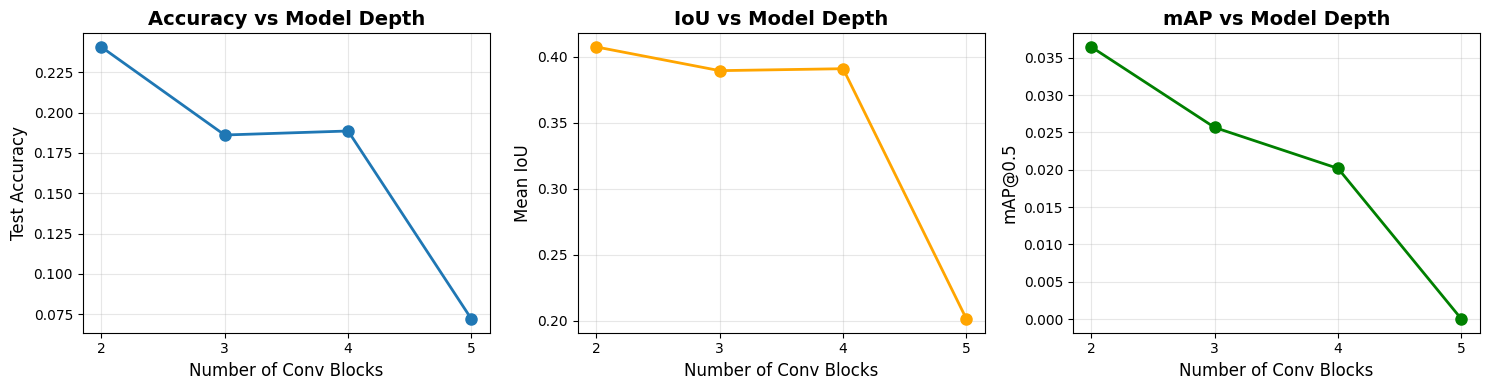


Convolution Blocks Analysis Summary:
------------------------------------------------------------
Best Accuracy: 0.2407 with 2 blocks
Best IoU: 0.4074 with 2 blocks
Best mAP: 0.0364 with 2 blocks

Note: Deeper models may perform better but require more computation.
------------------------------------------------------------


In [ ]:
# Visualize Convolution Blocks Results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

blocks = [r['num_blocks'] for r in conv_results]
accs = [r['test_acc'] for r in conv_results]
ious = [r['test_iou'] for r in conv_results]
maps = [r['test_map'] for r in conv_results]

axes[0].plot(blocks, accs, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Conv Blocks', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Model Depth', fontsize=14, fontweight='bold')
axes[0].set_xticks(blocks)
axes[0].grid(True, alpha=0.3)

axes[1].plot(blocks, ious, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Number of Conv Blocks', fontsize=12)
axes[1].set_ylabel('Mean IoU', fontsize=12)
axes[1].set_title('IoU vs Model Depth', fontsize=14, fontweight='bold')
axes[1].set_xticks(blocks)
axes[1].grid(True, alpha=0.3)

axes[2].plot(blocks, maps, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Number of Conv Blocks', fontsize=12)
axes[2].set_ylabel('mAP@0.5', fontsize=12)
axes[2].set_title('mAP vs Model Depth', fontsize=14, fontweight='bold')
axes[2].set_xticks(blocks)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nConvolution Blocks Analysis Summary:")
print("-" * 60)
best_acc_idx = np.argmax(accs)
best_iou_idx = np.argmax(ious)
best_map_idx = np.argmax(maps)
print(f"Best Accuracy: {accs[best_acc_idx]:.4f} with {blocks[best_acc_idx]} blocks")
print(f"Best IoU: {ious[best_iou_idx]:.4f} with {blocks[best_iou_idx]} blocks")
print(f"Best mAP: {maps[best_map_idx]:.4f} with {blocks[best_map_idx]} blocks")
print(f"\nNote: Deeper models may perform better but require more computation.")
print("-" * 60)

## 3. Filter Size Analysis

In [ ]:
# Experiment 3: Filter Size (Kernel Size)
filter_sizes = [3, 5, 7]
filter_results = []

print("Testing different filter sizes...")
for filter_size in filter_sizes:
    print(f"\n{'='*50}")
    print(f"Training with filter size: {filter_size}x{filter_size}")
    print('='*50)
    
    model = FlexibleCNN(
        num_classes=37, 
        lr=1e-3, 
        bbox_loss_weight=5.0, 
        bbox_lr_mult=2,
        num_conv_blocks=4,
        filter_size=filter_size
    )
    trainer = pl.Trainer(
        max_epochs=50,
        accelerator=device,
        log_every_n_steps=10,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    
    trainer.fit(model, train_loader, valid_loader)
    test_results = trainer.test(model, test_loader, verbose=False)
    
    result = {
        'filter_size': filter_size,
        'test_acc': test_results[0]['test_acc'],
        'test_iou': test_results[0].get('test_mean_iou', 0),
        'test_map': test_results[0].get('test_map', 0),
        'test_loss': test_results[0]['test_loss']
    }
    filter_results.append(result)
    print(f"Results: Acc={result['test_acc']:.4f}, IoU={result['test_iou']:.4f}, mAP={result['test_map']:.4f}")

print("\n" + "="*50)
print("Filter Size Experiment Complete!")
print("="*50)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing different filter sizes...

Training with filter size: 3x3
Epoch 19: 100%|██████████| 41/41 [00:22<00:00,  1.80it/s, v_num=69, train_loss=2.800, train_acc=0.286, val_loss=3.080, val_acc=0.148, val_iou=0.367, val_map=0.015]    

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 41/41 [00:23<00:00,  1.78it/s, v_num=69, train_loss=2.800, train_acc=0.286, val_loss=3.080, val_acc=0.148, val_iou=0.367, val_map=0.015]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 19: 100%|██████████| 41/41 [00:30<00:00,  1.34it/s, v_num=71, train_loss=2.450, train_acc=0.286, val_loss=3.190, val_acc=0.137, val_iou=0.400, val_map=0.0165]   

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 41/41 [00:31<00:00,  1.32it/s, v_num=71, train_loss=2.450, train_acc=0.286, val_loss=3.190, val_acc=0.137, val_iou=0.400, val_map=0.0165]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  2.77it/s]
Results: Acc=0.1191, IoU=0.3787, mAP=0.0120

Filter Size Experiment Complete!


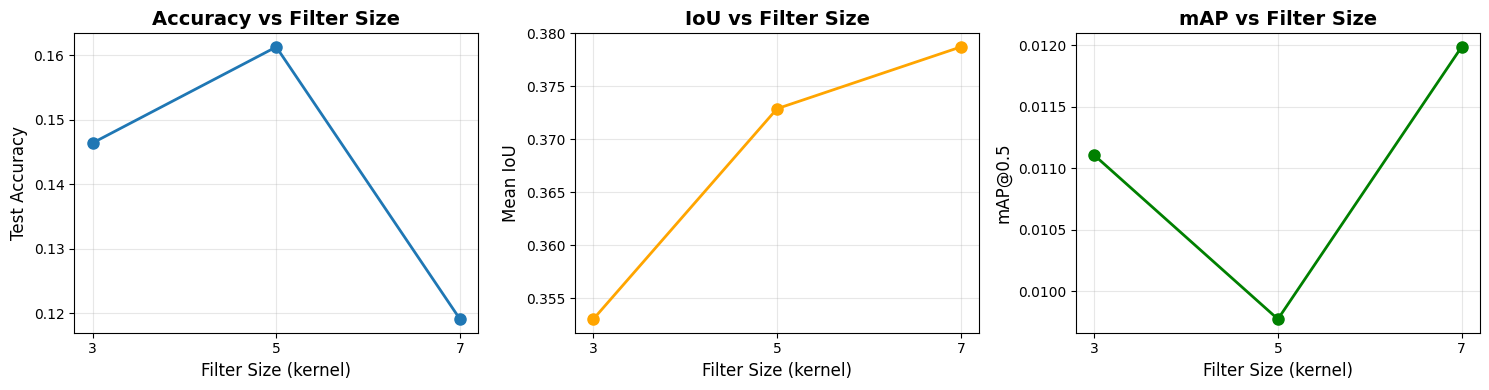


Filter Size Analysis Summary:
------------------------------------------------------------
Best Accuracy: 0.1613 with 5x5 filters
Best IoU: 0.3787 with 7x7 filters
Best mAP: 0.0120 with 7x7 filters

Note: Larger filters capture broader context but increase computation.
------------------------------------------------------------


In [ ]:
# Visualize Filter Size Results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [r['filter_size'] for r in filter_results]
accs = [r['test_acc'] for r in filter_results]
ious = [r['test_iou'] for r in filter_results]
maps = [r['test_map'] for r in filter_results]

axes[0].plot(filters, accs, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Filter Size (kernel)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Filter Size', fontsize=14, fontweight='bold')
axes[0].set_xticks(filters)
axes[0].grid(True, alpha=0.3)

axes[1].plot(filters, ious, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Filter Size (kernel)', fontsize=12)
axes[1].set_ylabel('Mean IoU', fontsize=12)
axes[1].set_title('IoU vs Filter Size', fontsize=14, fontweight='bold')
axes[1].set_xticks(filters)
axes[1].grid(True, alpha=0.3)

axes[2].plot(filters, maps, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Filter Size (kernel)', fontsize=12)
axes[2].set_ylabel('mAP@0.5', fontsize=12)
axes[2].set_title('mAP vs Filter Size', fontsize=14, fontweight='bold')
axes[2].set_xticks(filters)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nFilter Size Analysis Summary:")
print("-" * 60)
best_acc_idx = np.argmax(accs)
best_iou_idx = np.argmax(ious)
best_map_idx = np.argmax(maps)
print(f"Best Accuracy: {accs[best_acc_idx]:.4f} with {filters[best_acc_idx]}x{filters[best_acc_idx]} filters")
print(f"Best IoU: {ious[best_iou_idx]:.4f} with {filters[best_iou_idx]}x{filters[best_iou_idx]} filters")
print(f"Best mAP: {maps[best_map_idx]:.4f} with {filters[best_map_idx]}x{filters[best_map_idx]} filters")
print(f"\nNote: Larger filters capture broader context but increase computation.")
print("-" * 60)

## 4. Batch Size Analysis

In [ ]:
# Experiment 4: Batch Size
batch_sizes = [16, 32, 64, 128]
batch_results = []

print("Testing different batch sizes...")
for batch_size in batch_sizes:
    print(f"\n{'='*50}")
    print(f"Training with batch size: {batch_size}")
    print('='*50)
    
    # Create new data loaders with different batch size
    train_loader_exp = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                                  num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    valid_loader_exp = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, 
                                  num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader_exp = DataLoader(test_ds, batch_size=batch_size, shuffle=False, 
                                 num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    
    model = FlexibleCNN(
        num_classes=37, 
        lr=1e-3, 
        bbox_loss_weight=5.0, 
        bbox_lr_mult=2,
        num_conv_blocks=4
    )
    trainer = pl.Trainer(
        max_epochs=50,
        accelerator=device,
        log_every_n_steps=10,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    
    trainer.fit(model, train_loader_exp, valid_loader_exp)
    test_results = trainer.test(model, test_loader_exp, verbose=False)
    
    result = {
        'batch_size': batch_size,
        'test_acc': test_results[0]['test_acc'],
        'test_iou': test_results[0].get('test_mean_iou', 0),
        'test_map': test_results[0].get('test_map', 0),
        'test_loss': test_results[0]['test_loss']
    }
    batch_results.append(result)
    print(f"Results: Acc={result['test_acc']:.4f}, IoU={result['test_iou']:.4f}, mAP={result['test_map']:.4f}")

print("\n" + "="*50)
print("Batch Size Experiment Complete!")
print("="*50)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing different batch sizes...

Training with batch size: 16
Epoch 19: 100%|██████████| 161/161 [00:25<00:00,  6.20it/s, v_num=72, train_loss=3.730, train_acc=0.000, val_loss=3.770, val_acc=0.0628, val_iou=0.000, val_map=0.000] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 161/161 [00:26<00:00,  6.15it/s, v_num=72, train_loss=3.730, train_acc=0.000, val_loss=3.770, val_acc=0.0628, val_iou=0.000, val_map=0.000]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 19: 100%|██████████| 21/21 [00:22<00:00,  0.95it/s, v_num=75, train_loss=2.920, train_acc=0.143, val_loss=3.030, val_acc=0.147, val_iou=0.348, val_map=0.00634]  

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 21/21 [00:22<00:00,  0.94it/s, v_num=75, train_loss=2.920, train_acc=0.143, val_loss=3.030, val_acc=0.147, val_iou=0.348, val_map=0.00634]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 4/4 [00:01<00:00,  2.41it/s]
Results: Acc=0.1489, IoU=0.3344, mAP=0.0096

Batch Size Experiment Complete!


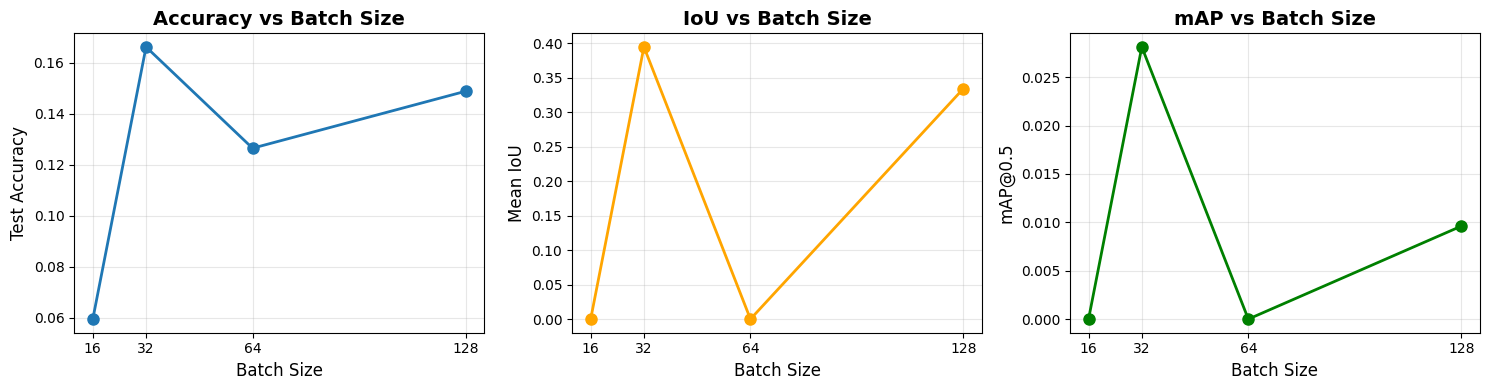


Batch Size Analysis Summary:
------------------------------------------------------------
Best Accuracy: 0.1663 with batch size 32
Best IoU: 0.3947 with batch size 32
Best mAP: 0.0281 with batch size 32

Note: Larger batches provide stable gradients but may miss finer details.
------------------------------------------------------------


In [ ]:
# Visualize Batch Size Results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

batches = [r['batch_size'] for r in batch_results]
accs = [r['test_acc'] for r in batch_results]
ious = [r['test_iou'] for r in batch_results]
maps = [r['test_map'] for r in batch_results]

axes[0].plot(batches, accs, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Batch Size', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Batch Size', fontsize=14, fontweight='bold')
axes[0].set_xticks(batches)
axes[0].grid(True, alpha=0.3)

axes[1].plot(batches, ious, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Batch Size', fontsize=12)
axes[1].set_ylabel('Mean IoU', fontsize=12)
axes[1].set_title('IoU vs Batch Size', fontsize=14, fontweight='bold')
axes[1].set_xticks(batches)
axes[1].grid(True, alpha=0.3)

axes[2].plot(batches, maps, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Batch Size', fontsize=12)
axes[2].set_ylabel('mAP@0.5', fontsize=12)
axes[2].set_title('mAP vs Batch Size', fontsize=14, fontweight='bold')
axes[2].set_xticks(batches)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nBatch Size Analysis Summary:")
print("-" * 60)
best_acc_idx = np.argmax(accs)
best_iou_idx = np.argmax(ious)
best_map_idx = np.argmax(maps)
print(f"Best Accuracy: {accs[best_acc_idx]:.4f} with batch size {batches[best_acc_idx]}")
print(f"Best IoU: {ious[best_iou_idx]:.4f} with batch size {batches[best_iou_idx]}")
print(f"Best mAP: {maps[best_map_idx]:.4f} with batch size {batches[best_map_idx]}")
print(f"\nNote: Larger batches provide stable gradients but may miss finer details.")
print("-" * 60)

## 5. Comprehensive Comparison

In [ ]:
# Create comprehensive comparison table
import pandas as pd

print("\n" + "="*70)
print("HYPERPARAMETER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*70)

# Learning Rate Summary
print("\n1. LEARNING RATE ANALYSIS")
print("-" * 70)
lr_df = pd.DataFrame(lr_results)
print(lr_df.to_string(index=False))
print(f"\nOptimal LR: {lr_df.loc[lr_df['test_acc'].idxmax(), 'lr']:.0e} (based on accuracy)")

# Convolution Blocks Summary
print("\n2. CONVOLUTION BLOCKS ANALYSIS")
print("-" * 70)
conv_df = pd.DataFrame(conv_results)
print(conv_df.to_string(index=False))
print(f"\nOptimal Depth: {conv_df.loc[conv_df['test_acc'].idxmax(), 'num_blocks']} blocks")

# Filter Size Summary
print("\n3. FILTER SIZE ANALYSIS")
print("-" * 70)
filter_df = pd.DataFrame(filter_results)
print(filter_df.to_string(index=False))
print(f"\nOptimal Filter: {filter_df.loc[filter_df['test_acc'].idxmax(), 'filter_size']}x{filter_df.loc[filter_df['test_acc'].idxmax(), 'filter_size']}")

# Batch Size Summary
print("\n4. BATCH SIZE ANALYSIS")
print("-" * 70)
batch_df = pd.DataFrame(batch_results)
print(batch_df.to_string(index=False))
print(f"\nOptimal Batch Size: {batch_df.loc[batch_df['test_acc'].idxmax(), 'batch_size']}")

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)
print("• Learning Rate: Higher LR converges faster but may overshoot; lower LR is stable")
print("• Model Depth: Deeper models capture complex features but risk overfitting")
print("• Filter Size: Larger filters see broader context; 3x3 is computationally efficient")
print("• Batch Size: Larger batches stabilize training; smaller batches add regularization")
print("="*70)


HYPERPARAMETER ANALYSIS - COMPREHENSIVE SUMMARY

1. LEARNING RATE ANALYSIS
----------------------------------------------------------------------
    lr  test_acc  test_iou  test_map  test_loss
0.0001  0.315136  0.442979  0.071576   2.453316
0.0005  0.193548  0.445239  0.040509   3.451160
0.0010  0.223325  0.411035  0.038274   2.774554
0.0050  0.027295  0.201267  0.000000   3.896117
0.0100  0.027295  0.201267  0.000193   3.896276

Optimal LR: 1e-04 (based on accuracy)

2. CONVOLUTION BLOCKS ANALYSIS
----------------------------------------------------------------------
 num_blocks  test_acc  test_iou  test_map  test_loss
          2  0.240695  0.407420  0.036440   2.778175
          3  0.186104  0.389464  0.025656   2.962560
          4  0.188586  0.390935  0.020171   3.002253
          5  0.071960  0.201267  0.000000   3.677884

Optimal Depth: 2 blocks

3. FILTER SIZE ANALYSIS
----------------------------------------------------------------------
 filter_size  test_acc  test_iou  tes

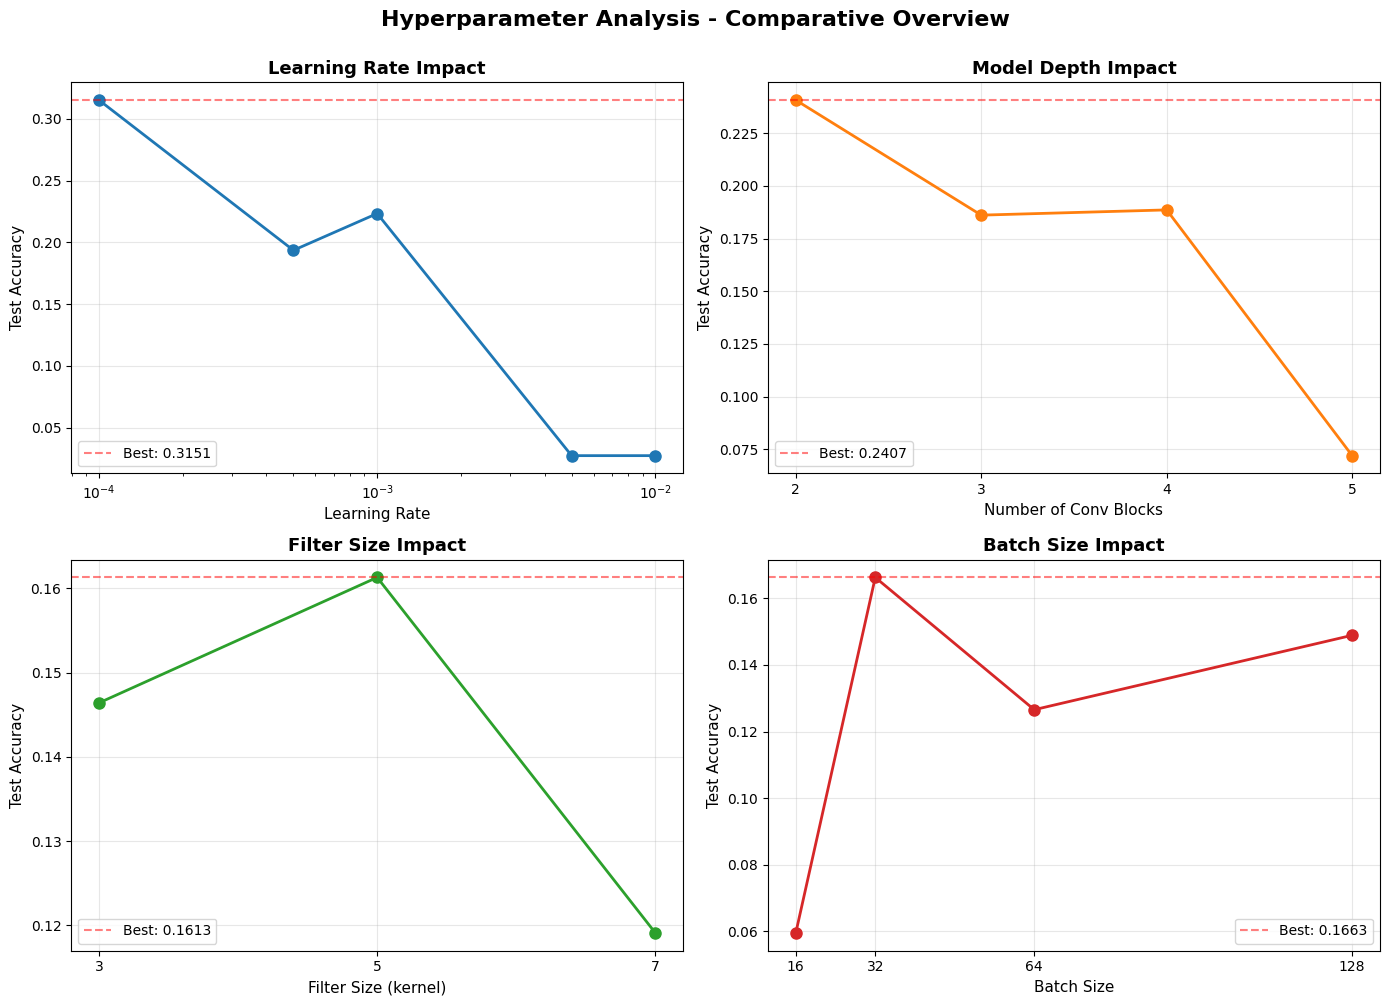

In [ ]:
# Create a combined visualization comparing all hyperparameters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Learning Rate
ax = axes[0, 0]
lrs = [r['lr'] for r in lr_results]
accs_lr = [r['test_acc'] for r in lr_results]
ax.plot(lrs, accs_lr, 'o-', linewidth=2, markersize=8, color='#1f77b4')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Learning Rate Impact', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=max(accs_lr), color='r', linestyle='--', alpha=0.5, label=f'Best: {max(accs_lr):.4f}')
ax.legend()

# 2. Number of Convolution Blocks
ax = axes[0, 1]
blocks = [r['num_blocks'] for r in conv_results]
accs_conv = [r['test_acc'] for r in conv_results]
ax.plot(blocks, accs_conv, 'o-', linewidth=2, markersize=8, color='#ff7f0e')
ax.set_xlabel('Number of Conv Blocks', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Model Depth Impact', fontsize=13, fontweight='bold')
ax.set_xticks(blocks)
ax.grid(True, alpha=0.3)
ax.axhline(y=max(accs_conv), color='r', linestyle='--', alpha=0.5, label=f'Best: {max(accs_conv):.4f}')
ax.legend()

# 3. Filter Size
ax = axes[1, 0]
filters = [r['filter_size'] for r in filter_results]
accs_filter = [r['test_acc'] for r in filter_results]
ax.plot(filters, accs_filter, 'o-', linewidth=2, markersize=8, color='#2ca02c')
ax.set_xlabel('Filter Size (kernel)', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Filter Size Impact', fontsize=13, fontweight='bold')
ax.set_xticks(filters)
ax.grid(True, alpha=0.3)
ax.axhline(y=max(accs_filter), color='r', linestyle='--', alpha=0.5, label=f'Best: {max(accs_filter):.4f}')
ax.legend()

# 4. Batch Size
ax = axes[1, 1]
batches = [r['batch_size'] for r in batch_results]
accs_batch = [r['test_acc'] for r in batch_results]
ax.plot(batches, accs_batch, 'o-', linewidth=2, markersize=8, color='#d62728')
ax.set_xlabel('Batch Size', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Batch Size Impact', fontsize=13, fontweight='bold')
ax.set_xticks(batches)
ax.grid(True, alpha=0.3)
ax.axhline(y=max(accs_batch), color='r', linestyle='--', alpha=0.5, label=f'Best: {max(accs_batch):.4f}')
ax.legend()

plt.suptitle('Hyperparameter Analysis - Comparative Overview', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()